In [38]:
# ===== IMPORT LIBRARIES FOR TFT =====
# System & Data Processing
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import DatetimeIndex

# Financial Tools
import yfinance as yf
import pandas_ta as ta
from hmmlearn import hmm

# PyTorch & Lightning Ecosystem
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

# PyTorch Forecasting
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss, MAE, SMAPE, PoissonLoss

# Sklearn Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, mean_absolute_error, mean_squared_error
)
from sklearn.preprocessing import RobustScaler

# --- CONFIGURATION ---
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) # Để xem hết các cột dữ liệu

# --- CHECK GPU ---
print(f"PyTorch version: {torch.__version__}")
print(f"Lightning version: {pl.__version__}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    accelerator = "gpu"
    devices = 1
    torch.set_float32_matmul_precision('medium') # Tối ưu hóa cho RTX 3000 series
else:
    print("NO GPU DETECTED. USING CPU.")
    accelerator = "cpu"
    devices = "auto"

PyTorch version: 2.10.0+cu128
Lightning version: 2.6.1
GPU: NVIDIA GeForce RTX 3060 Ti


In [39]:
tickers = [
    "SPY",   
    "QQQ",   
    "IWM",   
    "TLT",   
    "GLD",   
    "NVDA",  
    "JPM",   
    "XOM",   
    "JNJ",   
    "VNQ"    
]

# List để chứa dữ liệu tạm
all_data = []

for ticker in tickers:

    df = yf.Ticker(ticker).history(period="max", auto_adjust=True)
    df.drop(["Dividends", "Stock Splits"], axis=1, inplace=True)

    df = df.loc["1990-01-01":].copy()
    
    if len(df) > 0:
        # Định danh mã cổ phiếu
        df['Symbol'] = ticker 
        
        # Reset index để đưa Date vào làm một cột
        df = df.reset_index()
        
        df['Returns'] = df['Close'].pct_change()
        
        df = df.dropna()
        
        all_data.append(df)

# 2. Gộp tất cả lại thành một bảng dài (Long Format)
final_df = pd.concat(all_data, ignore_index=True)

# Sắp xếp lại cho đẹp: Theo Mã -> Theo Ngày
final_df = final_df.sort_values(by=['Symbol', 'Date'])

final_df

,Date,Open,High,Low,Close,Volume,Capital Gains,Symbol,Returns
27479,2004-11-19 00:00:00-05:00,44.490002,44.919998,44.470001,44.779999,11655300,0.0,GLD,0.009013
27480,2004-11-22 00:00:00-05:00,44.750000,44.970001,44.740002,44.950001,11996000,0.0,GLD,0.003796
27481,2004-11-23 00:00:00-05:00,44.880001,44.919998,44.720001,44.750000,3169200,0.0,GLD,-0.004449
27482,2004-11-24 00:00:00-05:00,44.930000,45.049999,44.790001,45.049999,6105100,0.0,GLD,0.006704
27483,2004-11-26 00:00:00-05:00,45.250000,45.599998,45.060001,45.290001,3097700,0.0,GLD,0.005327
...,...,...,...,...,...,...,...,...,...
57811,2026-02-06 00:00:00-05:00,145.649192,148.579672,145.122702,148.063110,17216000,NaN,XOM,0.020331
57812,2026-02-09 00:00:00-05:00,148.271701,150.546546,147.645882,150.208801,21297300,NaN,XOM,0.014492
57813,2026-02-10 00:00:00-05:00,150.347887,150.775033,148.828019,150.586288,15800300,NaN,XOM,0.002513
57814,2026-02-11 00:00:00-05:00,152.950530,155.890923,152.553185,154.529999,23091500,NaN,XOM,0.026189


## Step 1: Hidden Markov Model - Regime Detection

In [40]:
split_date = '2016-01-01'

train_mask = final_df['Date'] < split_date
test_mask = final_df['Date'] >= split_date

train_data = final_df[train_mask].copy()
test_data = final_df[test_mask].copy()

print(f"Train period: {train_data['Date'].min()} to {train_data['Date'].max()} ({len(train_data)} samples)")
print(f"Test period: {test_data['Date'].min()} to {test_data['Date'].max()} ({len(test_data)} samples)")

print("\n" + "="*60)
print("STANDARDIZING RETURNS BY TICKER (Z-SCORE)")
print("="*60)

# Standardize returns for each ticker separately
for ticker in tickers:
    # Train data
    ticker_train_mask = train_data['Symbol'] == ticker
    train_returns = train_data.loc[ticker_train_mask, 'Returns']
    train_mean = train_returns.mean()
    train_std = train_returns.std()
    
    print(f"{ticker} - Train: mean={train_mean:.6f}, std={train_std:.6f}")
    
    # Standardize train
    train_data.loc[ticker_train_mask, 'Returns_Standardized'] = (train_returns - train_mean) / train_std
    
    # Standardize test using TRAIN 
    ticker_test_mask = test_data['Symbol'] == ticker
    test_returns = test_data.loc[ticker_test_mask, 'Returns']
    test_data.loc[ticker_test_mask, 'Returns_Standardized'] = (test_returns - train_mean) / train_std

print("\n" + "="*60)
print("FITTING HMM ON STANDARDIZED RETURNS")
print("="*60)

# Use standardized returns for HMM
returns_train = train_data['Returns_Standardized'].values.reshape(-1, 1)

n_regimes = 3
model_hmm = hmm.GaussianHMM(
    n_components=n_regimes,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

print("\nFitting HMM on TRAIN data (standardized returns, all 6 tickers)...")
model_hmm.fit(returns_train)

train_data['Regime'] = model_hmm.predict(returns_train)
train_regime_probs = model_hmm.predict_proba(returns_train)
for i in range(n_regimes):
    train_data[f'Regime_Prob_{i}'] = train_regime_probs[:, i]

returns_test = test_data['Returns_Standardized'].values.reshape(-1, 1)
test_data['Regime'] = model_hmm.predict(returns_test)
test_regime_probs = model_hmm.predict_proba(returns_test)
for i in range(n_regimes):
    test_data[f'Regime_Prob_{i}'] = test_regime_probs[:, i]

combined_data = pd.concat([train_data, test_data])

print("\n" + "="*60)
print("REGIME CHARACTERISTICS (TRAIN - STANDARDIZED RETURNS)")
print("="*60)
for i in range(n_regimes):
    regime_returns = train_data[train_data['Regime'] == i]['Returns_Standardized']
    print(f"\nRegime {i}:")
    print(f"  Mean Standardized Return: {regime_returns.mean():.4f}")
    print(f"  Std Standardized Return: {regime_returns.std():.4f}")
    print(f"  Count: {len(regime_returns)} days ({len(regime_returns)/len(train_data)*100:.1f}%)")

# Check regime distribution by ticker
print("\n" + "="*60)
print("REGIME DISTRIBUTION BY TICKER (TRAIN)")
print("="*60)
for ticker in tickers:
    ticker_data = train_data[train_data['Symbol'] == ticker]
    regime_dist = ticker_data['Regime'].value_counts(normalize=True).sort_index() * 100
    print(f"\n{ticker}:")
    for regime_id in range(n_regimes):
        pct = regime_dist.get(regime_id, 0)
        print(f"  Regime {regime_id}: {pct:.1f}%")

print("\n" + "="*60)
print("TRANSITION MATRIX")
print("="*60)
print(pd.DataFrame(model_hmm.transmat_,
                   columns=[f'To Regime {i}' for i in range(n_regimes)],
                   index=[f'From Regime {i}' for i in range(n_regimes)]))

print("\n" + "="*60)
print("REGIME DISTRIBUTION IN TEST DATA")
print("="*60)
for i in range(n_regimes):
    test_regime_count = (test_data['Regime'] == i).sum()
    print(f"Regime {i}: {test_regime_count} days ({test_regime_count/len(test_data)*100:.1f}%)")

combined_data[['Date', 'Symbol', 'Returns', 'Returns_Standardized', 'Regime', 'Regime_Prob_0', 'Regime_Prob_1', 'Regime_Prob_2']].head(10)

Train period: 1990-01-03 00:00:00-05:00 to 2015-12-31 00:00:00-05:00 (46858 samples)
Test period: 2016-01-04 00:00:00-05:00 to 2026-02-12 00:00:00-05:00 (25430 samples)

STANDARDIZING RETURNS BY TICKER (Z-SCORE)
SPY - Train: mean=0.000411, std=0.011905
QQQ - Train: mean=0.000380, std=0.018571
IWM - Train: mean=0.000402, std=0.015456
TLT - Train: mean=0.000311, std=0.008763
GLD - Train: mean=0.000374, std=0.012515
NVDA - Train: mean=0.001542, std=0.040739
JPM - Train: mean=0.000725, std=0.024801
XOM - Train: mean=0.000507, std=0.014824
JNJ - Train: mean=0.000582, std=0.013742
VNQ - Train: mean=0.000581, std=0.021472

FITTING HMM ON STANDARDIZED RETURNS

Fitting HMM on TRAIN data (standardized returns, all 6 tickers)...

REGIME CHARACTERISTICS (TRAIN - STANDARDIZED RETURNS)

Regime 0:
  Mean Standardized Return: -0.0203
  Std Standardized Return: 2.2686
  Count: 3821 days (8.2%)

Regime 1:
  Mean Standardized Return: -0.0089
  Std Standardized Return: 0.9682
  Count: 23936 days (51.1%)



,Date,Symbol,Returns,Returns_Standardized,Regime,Regime_Prob_0,Regime_Prob_1,Regime_Prob_2
27479,2004-11-19 00:00:00-05:00,GLD,0.009013,0.690320,2,3.641678e-161,3.374263e-102,1.000000
27480,2004-11-22 00:00:00-05:00,GLD,0.003796,0.273473,2,5.306295e-08,1.060201e-02,0.989398
27481,2004-11-23 00:00:00-05:00,GLD,-0.004449,-0.385423,2,3.313215e-06,2.931141e-02,0.970685
27482,2004-11-24 00:00:00-05:00,GLD,0.006704,0.505804,2,1.102453e-05,5.722372e-02,0.942765
27483,2004-11-26 00:00:00-05:00,GLD,0.005327,0.395817,2,2.314011e-05,9.597970e-02,0.903997
27484,2004-11-29 00:00:00-05:00,GLD,0.002429,0.164194,2,4.240234e-05,1.582965e-01,0.841661
27485,2004-11-30 00:00:00-05:00,GLD,-0.006167,-0.522708,2,8.480856e-05,2.779600e-01,0.721955
27486,2004-12-01 00:00:00-05:00,GLD,0.005762,0.430577,2,1.762282e-04,4.247344e-01,0.575089
27487,2004-12-02 00:00:00-05:00,GLD,-0.009476,-0.787048,2,3.798347e-04,6.514214e-01,0.348199
27488,2004-12-03 00:00:00-05:00,GLD,0.014460,1.125609,2,7.586078e-04,8.105364e-01,0.188705


Plotting regimes for all tickers...


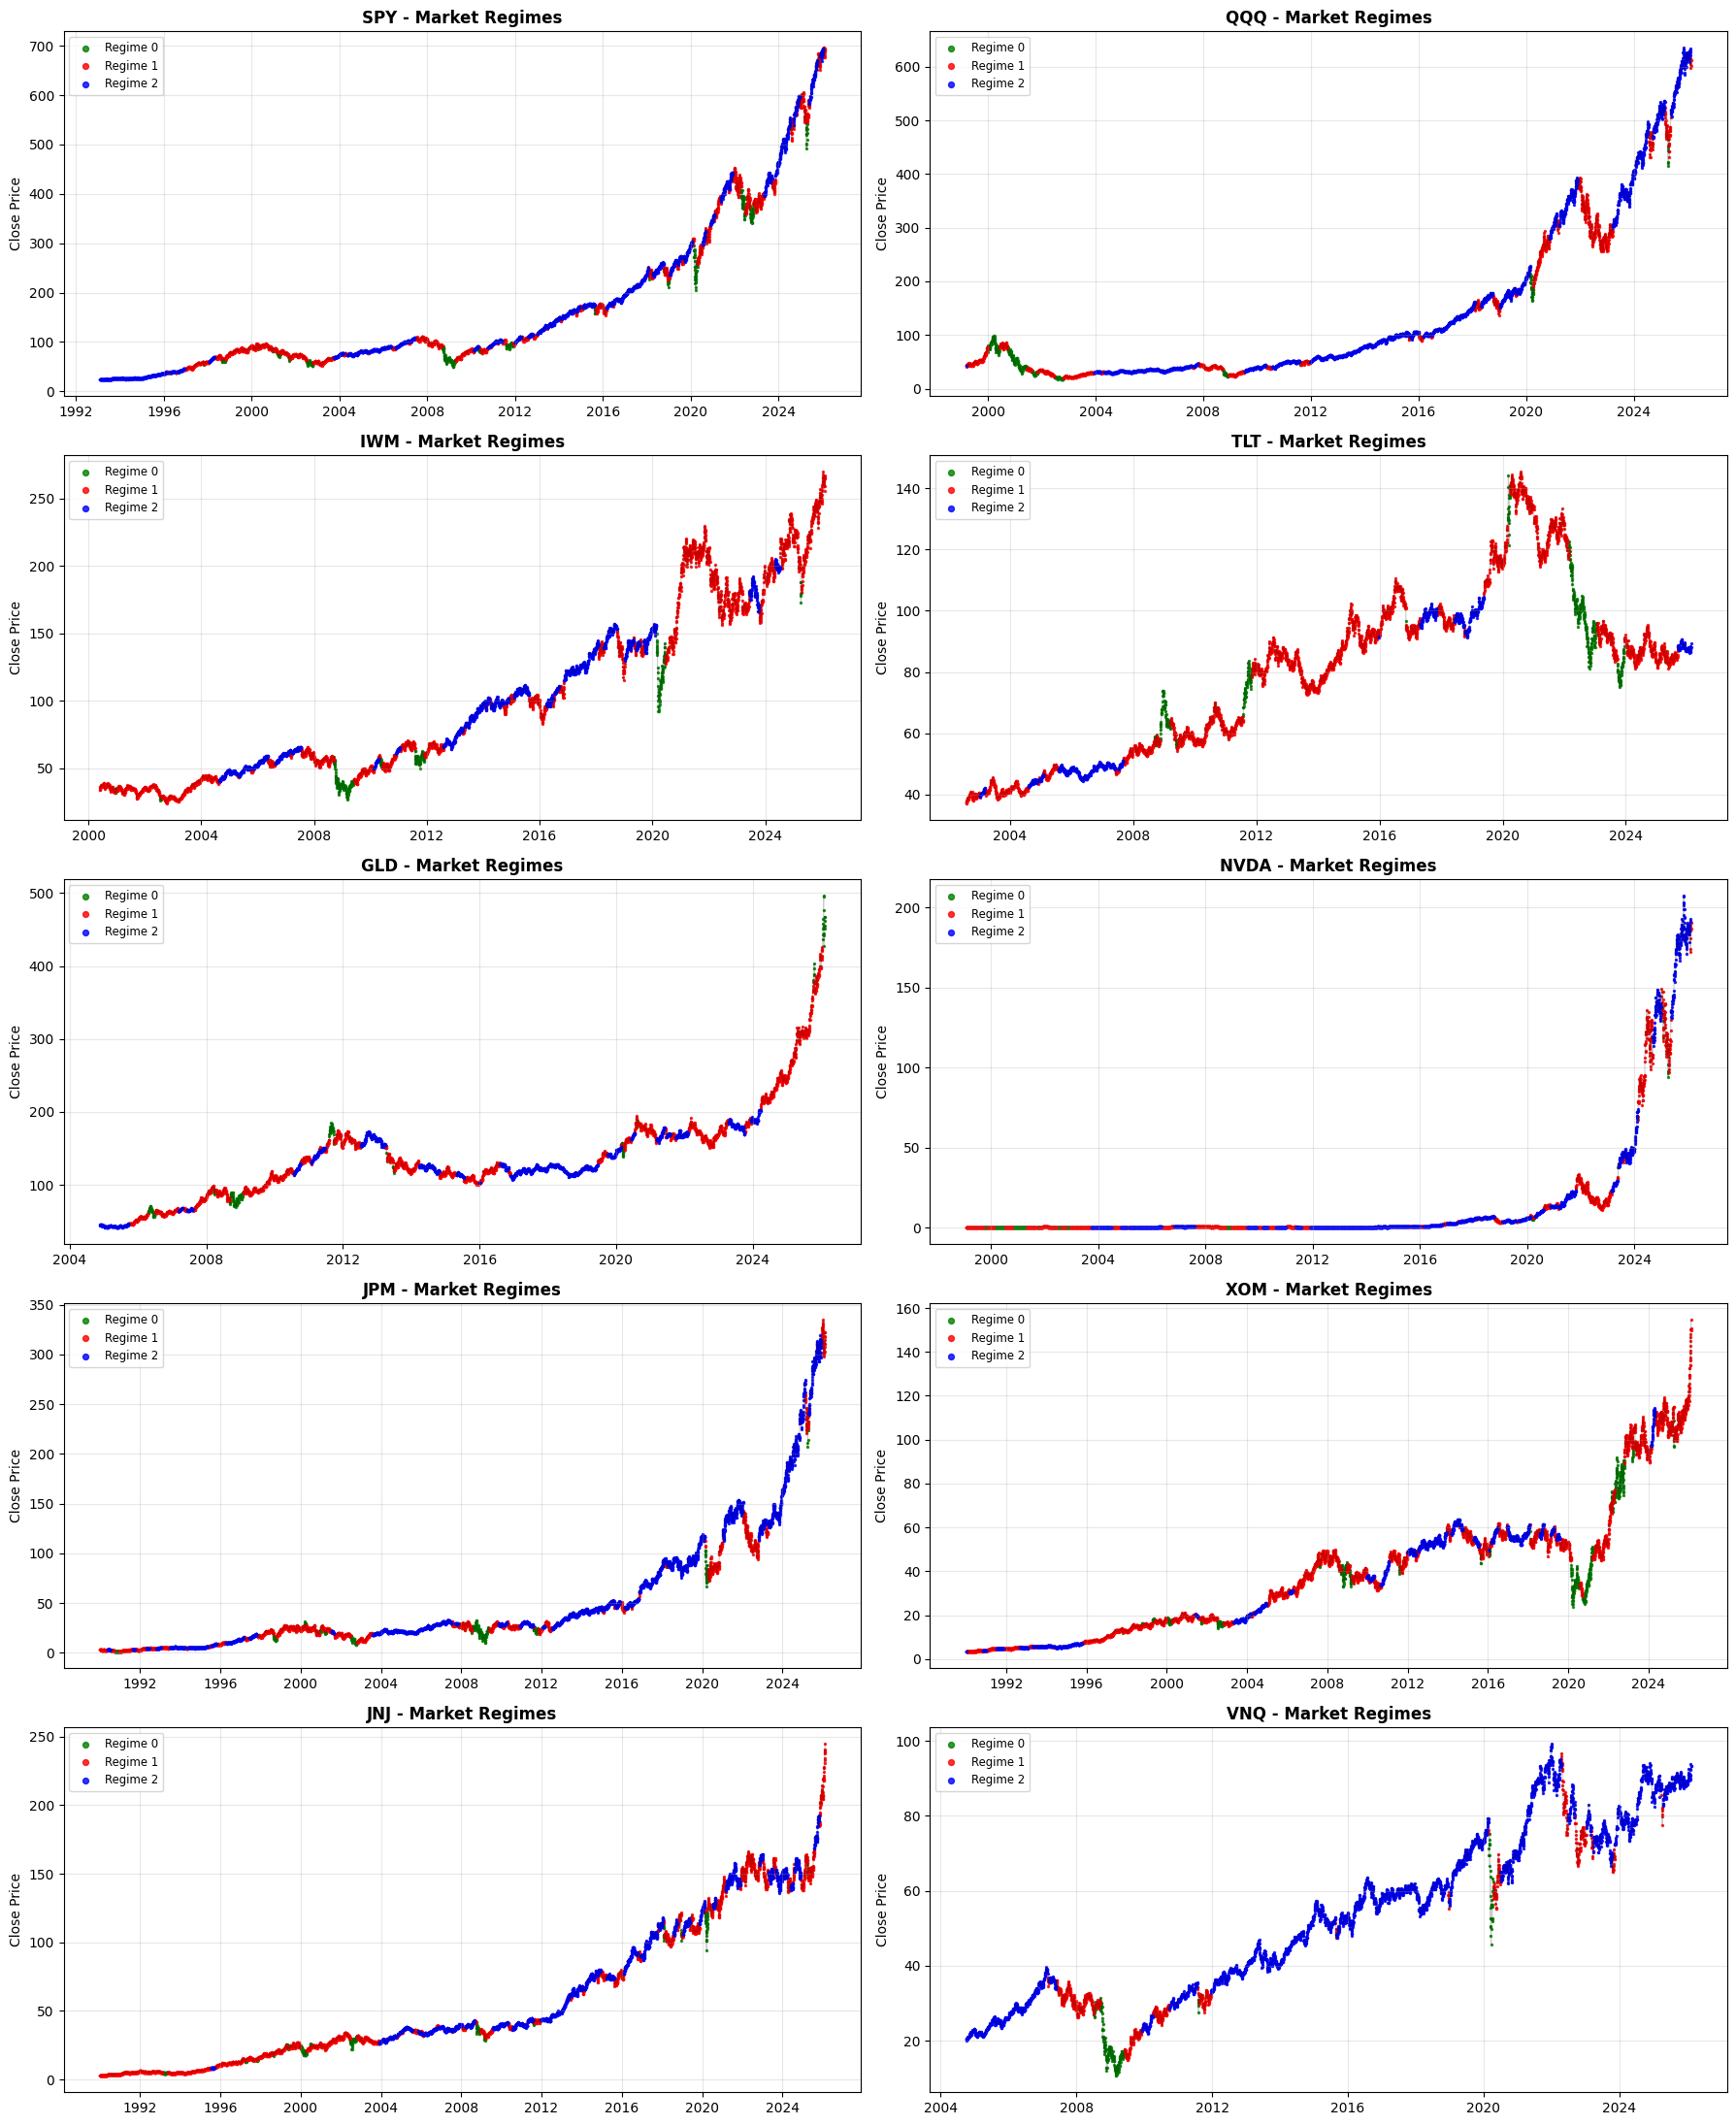

In [41]:
import matplotlib.pyplot as plt


tickers = [
    "SPY",   
    "QQQ",   
    "IWM",   
    "TLT",   
    "GLD",   
    "NVDA",  
    "JPM",   
    "XOM",   
    "JNJ",   
    "VNQ"    
]

fig, axes = plt.subplots(5, 2, figsize=(18, 22)) 
axes = axes.flatten() 

colors = ['green', 'red', 'blue']
regime_names = ['Regime 0', 'Regime 1', 'Regime 2']

print("Plotting regimes for all tickers...")

for idx, ticker in enumerate(tickers):
    if ticker not in combined_data['Symbol'].unique():
        print(f"Warning: {ticker} not found in combined_data. Skipping...")
        axes[idx].set_title(f'{ticker} - No Data Available')
        continue

    ax = axes[idx]
    
    ticker_data = combined_data[combined_data['Symbol'] == ticker].copy()
    ticker_data = ticker_data.set_index('Date')
    
    # Vẽ đường giá mờ làm nền
    ax.plot(ticker_data.index, ticker_data['Close'], linewidth=0.8, color='black', alpha=0.2)
    
    # Vẽ các điểm Regime
    for i in range(n_regimes):
        mask = ticker_data['Regime'] == i
        if mask.sum() > 0: # Chỉ vẽ nếu có dữ liệu của regime đó
            ax.scatter(ticker_data.index[mask], ticker_data['Close'][mask],
                       c=colors[i], s=2, alpha=0.8, label=regime_names[i])
    
    ax.set_ylabel('Close Price')
    ax.set_title(f'{ticker} - Market Regimes', fontweight='bold')
    ax.legend(loc='upper left', fontsize='small', markerscale=3)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 2: Feature Engineering - Technical Indicators

In [42]:
df = combined_data.copy()
df = df.sort_values(['Symbol', 'Date'])

print("\nNaN count by column:")
print(df.isnull().sum())
print("\nNaN in Capital Gains by ticker:")
for ticker in tickers:
    ticker_df = df[df['Symbol'] == ticker]
    nan_count = ticker_df['Capital Gains'].isnull().sum()
    print(f"  {ticker}: {nan_count}/{len(ticker_df)} NaN ({nan_count/len(ticker_df)*100:.1f}%)")

print("\n" + "="*60)
print("DROPPING 'Capital Gains' COLUMN")
print("="*60)
df = df.drop('Capital Gains', axis=1)

print("="*60)
print("BƯỚC 1: DỮ LIỆU SAU KHI HMM (BEFORE FEATURE ENGINEERING)")
print("="*60)
print(f"Total rows: {len(df)}")
for ticker in tickers:
    ticker_count = len(df[df['Symbol'] == ticker])
    print(f"  {ticker}: {ticker_count} rows")

all_ticker_dfs = []
for ticker in tickers:
    ticker_df = df[df['Symbol'] == ticker].copy()
    ticker_df = ticker_df.set_index('Date')
    
    # Trend Indicators
    ticker_df['SMA_10'] = ta.sma(ticker_df['Close'], length=10)
    ticker_df['SMA_50'] = ta.sma(ticker_df['Close'], length=50)
    ticker_df['EMA_12'] = ta.ema(ticker_df['Close'], length=12)
    ticker_df['EMA_26'] = ta.ema(ticker_df['Close'], length=26)
    
    # Momentum Indicators
    ticker_df['RSI'] = ta.rsi(ticker_df['Close'], length=14)
    macd = ta.macd(ticker_df['Close'])
    ticker_df['MACD'] = macd['MACD_12_26_9']
    ticker_df['MACD_signal'] = macd['MACDs_12_26_9']
    ticker_df['MACD_hist'] = macd['MACDh_12_26_9']
    
    # Volatility Indicators
    bbands = ta.bbands(ticker_df['Close'], length=20)
    if bbands is not None:
        bb_cols = bbands.columns.tolist()
        ticker_df['BB_upper'] = bbands[bb_cols[0]]
        ticker_df['BB_middle'] = bbands[bb_cols[1]]
        ticker_df['BB_lower'] = bbands[bb_cols[2]]
        ticker_df['BB_width'] = (ticker_df['BB_upper'] - ticker_df['BB_lower']) / ticker_df['BB_middle']
    
    ticker_df['ATR'] = ta.atr(ticker_df['High'], ticker_df['Low'], ticker_df['Close'], length=14)
    
    # Volume Indicators
    ticker_df['Volume_SMA'] = ta.sma(ticker_df['Volume'], length=20)
    ticker_df['Volume_ratio'] = ticker_df['Volume'] / ticker_df['Volume_SMA']
    
    # Price-based features
    ticker_df['Price_change_1d'] = ticker_df['Close'].pct_change(1)
    ticker_df['Price_change_5d'] = ticker_df['Close'].pct_change(5)
    ticker_df['Price_change_20d'] = ticker_df['Close'].pct_change(20)
    ticker_df['Volatility_20d'] = ticker_df['Returns'].rolling(window=20).std()
    
    # Distance from moving averages
    ticker_df['Dist_SMA10'] = (ticker_df['Close'] - ticker_df['SMA_10']) / ticker_df['SMA_10']
    ticker_df['Dist_SMA50'] = (ticker_df['Close'] - ticker_df['SMA_50']) / ticker_df['SMA_50']
    ticker_df['Dist_EMA12'] = (ticker_df['Close'] - ticker_df['EMA_12']) / ticker_df['EMA_12']
    
    # Position within Bollinger Bands
    ticker_df['BB_position'] = (ticker_df['Close'] - ticker_df['BB_lower']) / (ticker_df['BB_upper'] - ticker_df['BB_lower'])
    
    # Lag features
    for lag in [1, 2, 3, 5]:
        ticker_df[f'Return_lag_{lag}'] = ticker_df['Returns'].shift(lag)
    
    ticker_df = ticker_df.reset_index()
    
    print(f"\n{ticker} - BEFORE dropna: {len(ticker_df)} rows")
    ticker_df = ticker_df.dropna()
    print(f"{ticker} - AFTER dropna: {len(ticker_df)} rows (lost {len(df[df['Symbol'] == ticker]) - len(ticker_df)} rows)")
    
    all_ticker_dfs.append(ticker_df)

df = pd.concat(all_ticker_dfs, ignore_index=True)

print("\n" + "="*60)
print("BƯỚC 2: SAU KHI TÍNH FEATURES VÀ DROPNA")
print("="*60)
print(f"Total rows: {len(df)}")
for ticker in tickers:
    ticker_count = len(df[df['Symbol'] == ticker])
    print(f"  {ticker}: {ticker_count} rows")

print(f"\nFeatures created: {df.shape[1]} columns")
print(f"Data points: {df.shape[0]} rows")
print(f"\nFeature columns:")
print([col for col in df.columns if col not in ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol']])


NaN count by column:
Date                        0
Open                        0
High                        0
Low                         0
Close                       0
Volume                      0
Capital Gains           34091
Symbol                      0
Returns                     0
Returns_Standardized        0
Regime                      0
Regime_Prob_0               0
Regime_Prob_1               0
Regime_Prob_2               0
dtype: int64

NaN in Capital Gains by ticker:
  SPY: 0/8316 NaN (0.0%)
  QQQ: 0/6774 NaN (0.0%)
  IWM: 0/6466 NaN (0.0%)
  TLT: 0/5923 NaN (0.0%)
  GLD: 0/5341 NaN (0.0%)
  NVDA: 6806/6806 NaN (100.0%)
  JPM: 9095/9095 NaN (100.0%)
  XOM: 9095/9095 NaN (100.0%)
  JNJ: 9095/9095 NaN (100.0%)
  VNQ: 0/5377 NaN (0.0%)

DROPPING 'Capital Gains' COLUMN
BƯỚC 1: DỮ LIỆU SAU KHI HMM (BEFORE FEATURE ENGINEERING)
Total rows: 72288
  SPY: 8316 rows
  QQQ: 6774 rows
  IWM: 6466 rows
  TLT: 5923 rows
  GLD: 5341 rows
  NVDA: 6806 rows
  JPM: 9095 rows
  XOM: 9095 r

In [ ]:
# ===== CREATE TARGET VARIABLE (10-DAY FORWARD RETURN) =====

print("="*80)
print("CREATING TARGET VARIABLE - 10-DAY FORWARD RETURN")
print("="*80)

# Sort data
df = df.sort_values(["Symbol", "Date"])

print(f"Before creating target: {len(df)} rows")
for ticker in tickers:
    ticker_count = len(df[df["Symbol"] == ticker])
    print(f"  {ticker}: {ticker_count} rows")

# Create Return_10d_forward for each ticker separately
all_target_dfs = []
for ticker in tickers:
    ticker_df = df[df["Symbol"] == ticker].copy()
    
    print(f"{ticker}:")
    print(f"  Before creating target: {len(ticker_df)} rows")
    
    # Calculate 10-day forward return
    ticker_df["Return_10d_forward"] = ticker_df["Close"].pct_change(10).shift(-10)
    
    # Also create binary target for reference (optional)
    ticker_df["Target"] = (ticker_df["Return_10d_forward"] > 0).astype(int)
    
    # Remove last 10 rows (no future data)
    ticker_df = ticker_df[:-10]
    
    print(f"  After removing last 10 rows: {len(ticker_df)} rows")
    
    all_target_dfs.append(ticker_df)

# Concatenate all tickers
df = pd.concat(all_target_dfs, ignore_index=True)

print("" + "="*80)
print("TARGET VARIABLE SUMMARY")
print("="*80)
print(f"Total rows: {len(df)}")
for ticker in tickers:
    ticker_count = len(df[df["Symbol"] == ticker])
    print(f"  {ticker}: {ticker_count} rows")

print(f"Return_10d_forward statistics:")
print(f"  Mean: {df["Return_10d_forward"].mean():.6f}")
print(f"  Std:  {df["Return_10d_forward"].std():.6f}")
print(f"  Min:  {df["Return_10d_forward"].min():.6f}")
print(f"  Max:  {df["Return_10d_forward"].max():.6f}")

print(f"Target distribution (Up/Down):")
print(df["Target"].value_counts())
print(f"  Up (1): {(df["Target"]==1).sum()} ({(df["Target"]==1).mean()*100:.2f}%)")
print(f"  Down (0): {(df["Target"]==0).sum()} ({(df["Target"]==0).mean()*100:.2f}%)")

print("\n" + "="*60)
print("10-DAY TARGET DISTRIBUTION BY REGIME")
print("="*60)
for i in range(n_regimes):
    regime_data = df[df['Regime'] == i]
    up_pct = regime_data['Target'].mean() * 100
    print(f"Regime {i}: {up_pct:.2f}% up periods (10-day forward)")


CREATING TARGET VARIABLE - 10-DAY FORWARD RETURN
Before creating target: 71798 rows
  SPY: 8267 rows
  QQQ: 6725 rows
  IWM: 6417 rows
  TLT: 5874 rows
  GLD: 5292 rows
  NVDA: 6757 rows
  JPM: 9046 rows
  XOM: 9046 rows
  JNJ: 9046 rows
  VNQ: 5328 rows
SPY:
  Before creating target: 8267 rows
  After removing last 10 rows: 8257 rows
QQQ:
  Before creating target: 6725 rows
  After removing last 10 rows: 6715 rows
IWM:
  Before creating target: 6417 rows
  After removing last 10 rows: 6407 rows
TLT:
  Before creating target: 5874 rows
  After removing last 10 rows: 5864 rows
GLD:
  Before creating target: 5292 rows
  After removing last 10 rows: 5282 rows
NVDA:
  Before creating target: 6757 rows
  After removing last 10 rows: 6747 rows
JPM:
  Before creating target: 9046 rows
  After removing last 10 rows: 9036 rows
XOM:
  Before creating target: 9046 rows
  After removing last 10 rows: 9036 rows
JNJ:
  Before creating target: 9046 rows
  After removing last 10 rows: 9036 rows
VNQ:
 

In [ ]:
# ===== DATA PREPARATION FOR TFT =====
print("="*80)
print("TFT DATA PREPARATION")
print("="*80)

# Sort và Filter NaN -----
required_cols = [
    'Return_10d_forward', 'RSI', 'MACD', 'MACD_hist',
    'BB_width', 'ATR', 'Volatility_20d', 'Price_change_20d',
    'Dist_SMA10', 'Dist_SMA50',
    'Regime_Prob_0', 'Regime_Prob_1', 'Regime_Prob_2'
]

# Copy để tránh warning SettingWithCopy
df_clean = df.dropna(subset=required_cols).copy()
df_clean = df_clean.sort_values(['Symbol', 'Date']).reset_index(drop=True)

print(f"Filtered NaN & Sorted. Rows: {len(df)} -> {len(df_clean)}")

# Tạo time_idx sau khi đã lọc hết nhiễu
df_clean['time_idx'] = df_clean.groupby('Symbol').cumcount()
print("Created continuous time_idx")

# Thêm Calendar Features -----
# Chuyển sang string để dùng làm Categorical hoặc giữ nguyên int làm Reals
# Giữ int để dùng làm 'time_varying_known_reals'
df_clean['day_of_week'] = df_clean['Date'].dt.dayofweek.astype(str).astype('category') 
df_clean['day_of_month'] = df_clean['Date'].dt.day.astype(str).astype('category')
df_clean['month'] = df_clean['Date'].dt.month.astype(str).astype('category')
print("Added calendar features")

# Xử lý Symbol 
# String/category
df_clean['Symbol'] = df_clean['Symbol'].astype(str).astype('category')
print("Symbol converted to Category")

# Ép kiểu dữ liệu-----
float_cols = [
    'Return_10d_forward', 'RSI', 'MACD', 'MACD_hist',
    'BB_width', 'ATR', 'Volatility_20d', 'Price_change_20d',
    'Dist_SMA10', 'Dist_SMA50',
    'Regime_Prob_0', 'Regime_Prob_1', 'Regime_Prob_2',
    'Close', 'Returns' 
]

# Chỉ ép kiểu các cột tồn tại trong df
existing_float_cols = [c for c in float_cols if c in df_clean.columns]
for col in existing_float_cols:
    df_clean[col] = df_clean[col].astype('float32') # Dùng float32 cho nhẹ VRAM

print("Casted features to float32")

# Gap Check
print("\n" + "="*80)
print("DATA CONTINUITY CHECK")
print("="*80)
gap_found = False
for ticker in tickers:
    ticker_data = df_clean[df_clean['Symbol'] == ticker]
    
    # Kiểm tra xem có ngày nào bị nhảy cóc không (dựa vào diff ngày)
    idx_diff = ticker_data['time_idx'].diff().dropna()
    if (idx_diff != 1).any():
        print(f"WARNING: {ticker} has gaps in time_idx! Model might fail.")
        gap_found = True

if not gap_found:
    print("All tickers have continuous time_idx (Perfect for TFT).")

# Update global df
df = df_clean.copy()

print("\n" + "="*80)
print("TFT DATA PREPARATION COMPLETED")
print("="*80)
print(f"Final dataset: {len(df)} rows")
print(f"Features ready: {existing_float_cols}")

# Display sample
print("\nSample data:")
print(df[['Date', 'Symbol', 'time_idx', 'Return_10d_forward', 'Regime_Prob_0']].head())

TFT DATA PREPARATION
Filtered NaN & Sorted. Rows: 71698 -> 71698
Created continuous time_idx
Added calendar features
Symbol converted to Category
✓ Casted features to float32

DATA CONTINUITY CHECK
All tickers have continuous time_idx (Perfect for TFT).

TFT DATA PREPARATION COMPLETED
Final dataset: 71698 rows
Features ready: ['Return_10d_forward', 'RSI', 'MACD', 'MACD_hist', 'BB_width', 'ATR', 'Volatility_20d', 'Price_change_20d', 'Dist_SMA10', 'Dist_SMA50', 'Regime_Prob_0', 'Regime_Prob_1', 'Regime_Prob_2', 'Close', 'Returns']

Sample data:
                       Date Symbol  time_idx  Return_10d_forward  \
0 2005-02-01 00:00:00-05:00    GLD         0            0.011402   
1 2005-02-02 00:00:00-05:00    GLD         1            0.008539   
2 2005-02-03 00:00:00-05:00    GLD         2            0.025192   
3 2005-02-04 00:00:00-05:00    GLD         3            0.030866   
4 2005-02-07 00:00:00-05:00    GLD         4            0.055731   

   Regime_Prob_0  
0       0.000009  
1   

## Step 5: Train TFT Model (Temporal Fusion Transformer)

**TFT Architecture:**
- **Variable Selection Networks**: Tự động chọn features quan trọng
- **Gating Layers**: Kiểm soát information flow
- **Multi-Head Attention**: Focus vào timesteps quan trọng  
- **Entity Embeddings**: Học đặc trưng riêng cho từng ticker
- **Quantile Regression**: Dự đoán khoảng tin cậy (Q10, Q50, Q90)

**Chiến lược:**
1. Train model dự đoán Return 10 ngày tới (regression)
2. Sử dụng Quantile Loss để ước lượng uncertainty
3. Post-processing: Chuyển đổi median prediction sang Up/Down classification

In [ ]:
# ===== CREATE TIMESERIESDATASET FOR TFT =====
print("="*80)
print("CREATING TIMESERIESDATASET")
print("="*80)

# Feature Classification
static_categoricals = ['Symbol'] 

time_varying_known_categoricals = [
    'day_of_week',
    'day_of_month', 
    'month'
]

time_varying_known_reals = ['time_idx']

time_varying_unknown_reals = [
    'Close', 'Returns',
    'RSI', 'MACD', 'MACD_hist',
    'BB_width', 'ATR', 'Volatility_20d',
    'Price_change_20d',
    'Dist_SMA10', 'Dist_SMA50',
    'Regime_Prob_0', 'Regime_Prob_1', 'Regime_Prob_2'
]

target = 'Return_10d_forward'

# 2. Chia Train/Test 
print("\nSplitting Data...")

# Lấy thông tin timezone từ dòng đầu tiên của dữ liệu
# (Nếu dữ liệu không có timezone, biến này sẽ là None)
data_timezone = df['Date'].iloc[0].tzinfo

split_timestamp = pd.Timestamp('2016-01-01')

# Nếu dữ liệu có timezone, ta ép split_timestamp theo timezone đó
if data_timezone is not None:
    split_timestamp = split_timestamp.tz_localize(data_timezone)
    print(f"  Detected Timezone: {data_timezone} -> Adjusted split date to match.")

print(f"  Split Date used: {split_timestamp}")

train_data = df[df['Date'] < split_timestamp].copy()
test_data = df[df['Date'] >= split_timestamp].copy()

print(f"  Train samples: {len(train_data)}")
print(f"  Test samples:  {len(test_data)}")


# Tạo Dataset
print("\nCreating Training Dataset...")

max_encoder_length = 60   
max_prediction_length = 1 

training = TimeSeriesDataSet(
    train_data,
    time_idx='time_idx',
    target=target,
    group_ids=['Symbol'], 
    
    # Cấu hình độ dài chuỗi
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    
    # Phân loại Features
    static_categoricals=static_categoricals,
    time_varying_known_categoricals=time_varying_known_categoricals,
    time_varying_known_reals=time_varying_known_reals,
    time_varying_unknown_reals=time_varying_unknown_reals,
    
    # Normalization (Z-Score)
    target_normalizer=GroupNormalizer(
        groups=['Symbol'], 
        transformation=None 
    ),
    
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True
)

print("Training dataset created")

# Validation & Dataloaders

print("\nCreating Validation Dataset...")
validation = TimeSeriesDataSet.from_dataset(
    training, 
    test_data, 
    predict=False, 
    stop_randomization=True
)

# Cập nhật lại DataLoaders
batch_size = 64


train_dataloader = training.to_dataloader(
    train=True, 
    batch_size=batch_size, 
    num_workers=0
)


val_dataloader = validation.to_dataloader(
    train=False,  
    batch_size=batch_size * 2, 
    num_workers=0
)

print(f"\nDataLoaders ready. Batch size: {batch_size}")
print(f"  Encoder Length: {max_encoder_length}")
print(f"  Target Normalizer: GroupNormalizer (Z-Score)")

x, y = next(iter(train_dataloader))
print(f"\nData Shape Check:")
print(f"  Input (Cat): {x['encoder_cat'].shape}")
print(f"  Target: {y[0].shape}")


CREATING TIMESERIESDATASET

Splitting Data...
  Detected Timezone: America/New_York -> Adjusted split date to match.
  Split Date used: 2016-01-01 00:00:00-05:00
  Train samples: 46368
  Test samples:  25330

Creating Training Dataset...
Training dataset created

Creating Validation Dataset...

DataLoaders ready. Batch size: 64
  Encoder Length: 60
  Target Normalizer: GroupNormalizer (Z-Score)

Data Shape Check:
  Input (Cat): torch.Size([64, 60, 4])
  Target: torch.Size([64, 1])


In [ ]:
# ===== BUILD & TRAIN TFT MODEL =====
print("\n" + "="*80)
print("BUILDING TFT MODEL")
print("="*80)

# Cấu hình TFT
tft = TemporalFusionTransformer.from_dataset(
    training,
    
    # Hyperparameters
    learning_rate=0.001,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.2,
    hidden_continuous_size=16,
    
    # Loss function
    loss=QuantileLoss(),
    
    optimizer="adam", 
    
    # Logging
    log_interval=10, 
    reduce_on_plateau_patience=6,
)

print(f"TFT Model created successfully.")
print(f"   Total Parameters: {sum(p.numel() for p in tft.parameters()):,}")


# PyTorch Lightning Trainer 
print("\n" + "="*80)
print("CONFIGURING TRAINER")
print("="*80)

# 1. Early Stopping 
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-5,
    patience=15,
    verbose=True,
    mode="min"
)

# 2. Model Checkpoint 
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    dirpath="checkpoints/",       # Thư mục lưu
    filename="best-checkpoint",   # Tên file
    save_top_k=1,                 # Chỉ lưu 1 model tốt nhất
    mode="min"                    # Loss càng nhỏ càng tốt
)

# Trainer configuration
trainer = pl.Trainer(
    max_epochs=100,
    
    # Cấu hình GPU
    accelerator=accelerator,
    devices=devices,
    
    # Gradient Clipping
    gradient_clip_val=0.1,
    
    # Callbacks (Thêm checkpoint_callback)
    callbacks=[early_stop_callback, checkpoint_callback, LearningRateMonitor("epoch")],
    
    # Logger 
    logger=True, 
    
    # Tắt sanity check nếu muốn nhanh
    # num_sanity_val_steps=0 
)
print(f"Done Trainer configured")

# CHUẨN BỊ DATALOADERS

batch_size = 64 

train_dataloader = training.to_dataloader(
    train=True, 
    batch_size=batch_size, 
    num_workers=0 
)

val_dataloader = validation.to_dataloader(
    train=False, 
    batch_size=batch_size * 2, 
    num_workers=0
)


# 5. TRAINING
print("\n" + "="*80)
print("STARTING TRAINING...")
print("="*80)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

print("\n" + "="*80)
print("TRAINING COMPLETED")
print("="*80)


# 6. LOAD BEST MODEL 

# Load lại trọng số từ file checkpoint có val_loss thấp nhất
best_model_path = trainer.checkpoint_callback.best_model_path
print(f"Loading best model from: {best_model_path}")

best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

print(f"Best model loaded successfully!")
print(f"Final validation loss (Best): {trainer.callback_metrics.get('val_loss', 'N/A')}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



BUILDING TFT MODEL
TFT Model created successfully.
   Total Parameters: 282,470

CONFIGURING TRAINER
Done Trainer configured

STARTING TRAINING...



   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 493    | train | 0    
3  | prescalers                         | ModuleDict                      | 608    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 9.7 K  | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 57.5 K | train | 0    
6  | decoder_variable_selection         | VariableSelectionNetwork        | 7.4 K  | train | 0    
7  | static_context_variable_selection  | GatedResidualNetwork            | 16.8 K | train | 0    
8  

Epoch 0: 100%|██████████| 724/724 [01:28<00:00,  8.14it/s, v_num=28, train_loss_step=0.0188, val_loss=0.0181, train_loss_epoch=0.0207]

Metric val_loss improved. New best score: 0.018


Epoch 15: 100%|██████████| 724/724 [01:31<00:00,  7.91it/s, v_num=28, train_loss_step=0.0149, val_loss=0.0217, train_loss_epoch=0.0143] 

Monitored metric val_loss did not improve in the last 15 records. Best score: 0.018. Signaling Trainer to stop.


Epoch 15: 100%|██████████| 724/724 [01:31<00:00,  7.91it/s, v_num=28, train_loss_step=0.0149, val_loss=0.0217, train_loss_epoch=0.0143]

TRAINING COMPLETED!
Loading best model from: /home/nha506832/Đồ án ngành/checkpoints/best-checkpoint.ckpt
Best model loaded successfully!
Final validation loss (Best): 0.02169530652463436


In [ ]:
# ===== PREDICTIONS & POST-PROCESSING =====
# Chú thích: Dự đoán với TFT và convert Quantile Regression sang Classification
from sklearn.metrics import mean_squared_error
print("="*80)
print("MAKING PREDICTIONS WITH TFT")
print("="*80)

# Predict on Validation Set 
print("Predicting on validation set...")


# mode="raw" trả về cả output distribution (quantiles)
raw_output = best_tft.predict(val_dataloader, mode="raw", return_y=True, return_x=True)

# Lấy Predictions
# Shape chuẩn: (n_samples, prediction_length, n_quantiles)
preds = raw_output.output.prediction

# Lấy Actuals (Ground Truth)
# raw_output.y là một list, phần tử đầu tiên là target chính

targets = raw_output.y[0]

print(f"Predictions shape: {preds.shape}")
print(f"Samples: {preds.shape[0]}")
print(f"Time Steps: {preds.shape[1]}")
print(f"Quantiles: {preds.shape[2]} (Index 0=10%, 1=50%, 2=90%)")

# Extract Values -----

# Lấy Median (Quantile 0.5 - nằm ở index 3) cho bước dự báo đầu tiên (time index 0)
median_predictions = preds[:, 0, 3].cpu().numpy()

# Lấy Q10 (Quantile 0.1 - index 1) và Q90 (Quantile 0.9 - index 5)
q10_predictions = preds[:, 0, 1].cpu().numpy() 
q90_predictions = preds[:, 0, 5].cpu().numpy()

# Lấy giá trị thực tế (flatten ra mảng 1 chiều)
y_true_values = targets[:, 0].cpu().numpy()

print(f"\nExtracted values:")
print(f"Median Pred Range: [{median_predictions.min():.4f}, {median_predictions.max():.4f}]")
print(f"Actual Val Range:  [{y_true_values.min():.4f}, {y_true_values.max():.4f}]")

# Convert to Classification (Up/Down) -----
print("\n" + "="*80)
print("CONVERTING TO CLASSIFICATION")
print("="*80)

# Regression → Classification (DYNAMIC THRESHOLD)
# GIẢI PHÁP: Dùng Median của Predictions làm Threshold
# Lý do: Model bị positive bias, hầu hết dự báo > 0
# Logic: Nếu dự báo > median(predictions) → UP, ngược lại → DOWN

# Tính dynamic threshold
pred_threshold = np.median(median_predictions)
print(f"\nDynamic Threshold Analysis:")
print(f"Old Threshold (Fixed):    0.0")
print(f"New Threshold (Dynamic):  {pred_threshold:.6f}")
print(f"Mean Prediction:          {np.mean(median_predictions):.6f}")
print(f"Median Prediction:        {pred_threshold:.6f}")

# Apply dynamic threshold
y_pred_class = (median_predictions > pred_threshold).astype(int)
y_true_class = (y_true_values > 0).astype(int)

# Thống kê nhanh
total_samples = len(y_pred_class)
print(f"Binary Classification Summary:")
print(f"Predicted UP:   {(y_pred_class == 1).sum()} ({(y_pred_class == 1).sum() / total_samples * 100:.2f}%)")
print(f"Actual UP:      {(y_true_class == 1).sum()} ({(y_true_class == 1).sum() / total_samples * 100:.2f}%)")

# Evaluate Classification Performance 
print("\n" + "="*80)
print("CLASSIFICATION METRICS")
print("="*80)

accuracy = accuracy_score(y_true_class, y_pred_class)
precision = precision_score(y_true_class, y_pred_class, average='weighted', zero_division=0)
f1 = f1_score(y_true_class, y_pred_class, average='weighted')

# Recall cho từng lớp
down_recall = recall_score(y_true_class, y_pred_class, pos_label=0, zero_division=0)
up_recall = recall_score(y_true_class, y_pred_class, pos_label=1, zero_division=0)

print(f"Accuracy:     {accuracy:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"F1-Score:     {f1:.4f}")
print("-" * 30)
print(f"Down Recall:  {down_recall:.4f} (Khả năng bắt đáy/giảm)")
print(f"Up Recall:    {up_recall:.4f} (Khả năng bắt đỉnh/tăng)")

# Classification Report 
print("\n" + "-"*80)
print("CLASSIFICATION REPORT")
print("-"*80)
print(classification_report(y_true_class, y_pred_class, target_names=['Down (0)', 'Up (1)']))

# Regression Metrics 
print("\n" + "="*80)
print("REGRESSION METRICS")
print("="*80)

mae = mean_absolute_error(y_true_values, median_predictions)
rmse = np.sqrt(mean_squared_error(y_true_values, median_predictions))

print(f"MAE:  {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

# Quantile Coverage (Đánh giá rủi ro) 
print("\n" + "="*80)
print("QUANTILE PREDICTION COVERAGE")
print("="*80)

# Kiểm tra xem giá trị thực có nằm trong khoảng tin cậy 80% (Q10 - Q90) không
within_interval = ((y_true_values >= q10_predictions) & (y_true_values <= q90_predictions)).sum()
coverage = within_interval / len(y_true_values) * 100

print(f"80% Confidence Interval Coverage:")
print(f"  Expected: ~80.00%")
print(f"  Actual:   {coverage:.2f}%")
print(f"  Samples inside [Q10, Q90]: {within_interval}/{len(y_true_values)}")

if coverage < 70:
    print("Warning: Model is Under-confident (Khoảng dự báo quá hẹp)")
elif coverage > 90:
    print("Warning: Model is Over-confident (Khoảng dự báo quá rộng)")
else:
    print("Model Uncertainty Calibration is Good!")

print("="*80)

# PER-TICKER ANALYSIS 
print("\n" + "="*80)
print("DETAILED RESULTS BY TICKER")
print("="*80)

# Extract Symbol từ input data
symbols_list = []
for batch in val_dataloader:
    x, _ = batch
    # Symbol nằm ở encoder_cat[:,0,0] (static categorical đầu tiên)
    batch_symbols = x["encoder_cat"][:, 0, 0].cpu().numpy()
    symbols_list.extend(batch_symbols)

# Convert indices về tên ticker
import pandas as pd
symbol_mapping = dict(enumerate(test_data["Symbol"].cat.categories))
symbols = [symbol_mapping[int(idx)] for idx in symbols_list]

# Tạo DataFrame kết quả
results_df = pd.DataFrame({
    "Symbol": symbols,
    "Actual": y_true_values,
    "Predicted": median_predictions,
    "Q10": q10_predictions,
    "Q90": q90_predictions,
    "Actual_Class": y_true_class,
    "Predicted_Class": y_pred_class
})

# Metrics cho từng ticker
print("\n" + "Ticker".ljust(8) + "Samples".ljust(10) + "Accuracy".ljust(12) + "Precision".ljust(12) + "Recall".ljust(12) + "F1-Score".ljust(12) + "MAE")
print("-" * 80)

for ticker in sorted(results_df["Symbol"].unique()):
    ticker_data = results_df[results_df["Symbol"] == ticker]
    acc = accuracy_score(ticker_data["Actual_Class"], ticker_data["Predicted_Class"])
    prec = precision_score(ticker_data["Actual_Class"], ticker_data["Predicted_Class"], zero_division=0)
    rec = recall_score(ticker_data["Actual_Class"], ticker_data["Predicted_Class"], zero_division=0)
    f1 = f1_score(ticker_data["Actual_Class"], ticker_data["Predicted_Class"], zero_division=0)
    mae_ticker = mean_absolute_error(ticker_data["Actual"], ticker_data["Predicted"])
    print(f"{ticker.ljust(8)}{str(len(ticker_data)).ljust(10)}{acc:.4f}".ljust(12) + f"{prec:.4f}".ljust(12) + f"{rec:.4f}".ljust(12) + f"{f1:.4f}".ljust(12) + f"{mae_ticker:.6f}")

print("="*80)
print(f"\nResults saved to results_df DataFrame ({len(results_df)} samples)")



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAKING PREDICTIONS WITH TFT
Predicting on validation set...
Predictions shape: torch.Size([25330, 1, 7])
Samples: 25330
Time Steps: 1
Quantiles: 7 (Index 0=10%, 1=50%, 2=90%)

Extracted values:
Median Pred Range: [-0.0218, 0.0172]
Actual Val Range:  [-0.3682, 0.3915]

CONVERTING TO CLASSIFICATION

Dynamic Threshold Analysis:
Old Threshold (Fixed):    0.0
New Threshold (Dynamic):  0.003772
Mean Prediction:          0.003599
Median Prediction:        0.003772
Binary Classification Summary:
Predicted UP:   12665 (50.00%)
Actual UP:      14843 (58.60%)

CLASSIFICATION METRICS
Accuracy:     0.5280
Precision:    0.5428
F1-Score:     0.5315
------------------------------
Down Recall:  0.5338 (Khả năng bắt đáy/giảm)
Up Recall:    0.5239 (Khả năng bắt đỉnh/tăng)

--------------------------------------------------------------------------------
CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   suppo

CONFUSION MATRIX - TFT


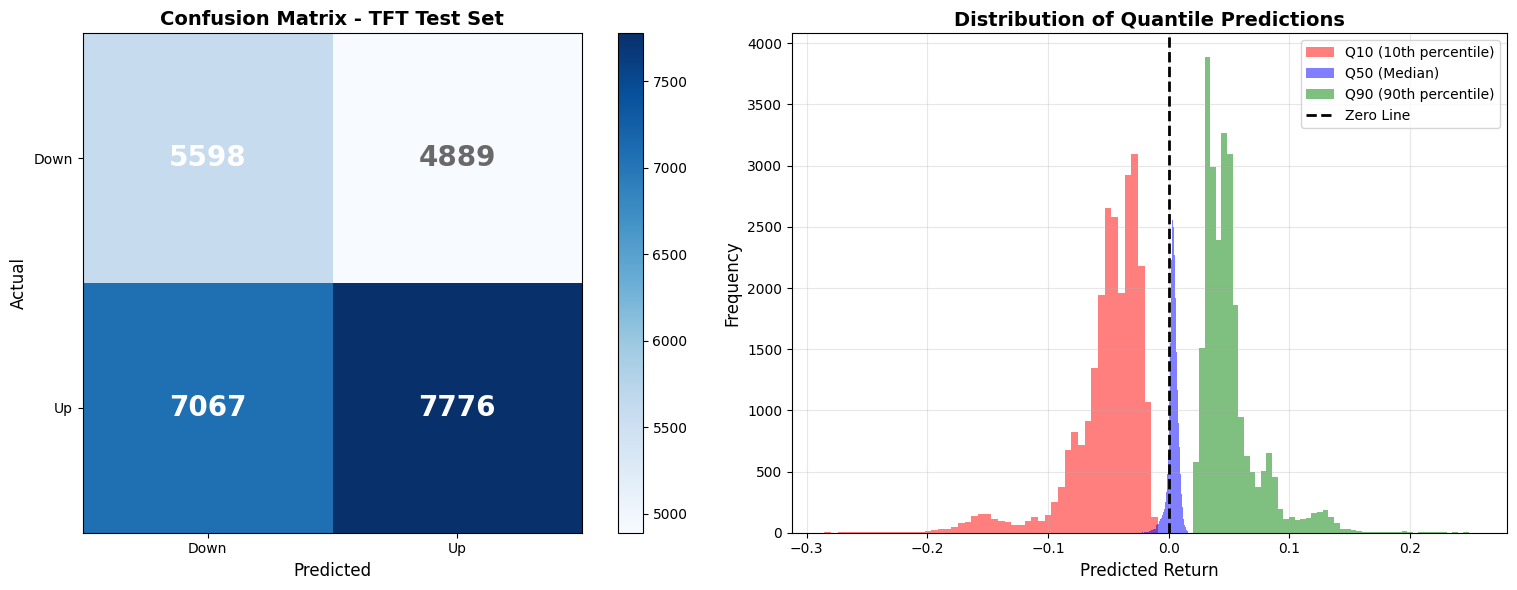


Confusion Matrix Values:
  True Negatives:  5598
  False Positives: 4889
  False Negatives: 7067
  True Positives:  7776

Metrics:
  Overall Precision: 0.6140
  Overall Recall:    0.5239
  Overall Accuracy:  0.5280

PREDICTION VS ACTUAL SCATTER PLOT


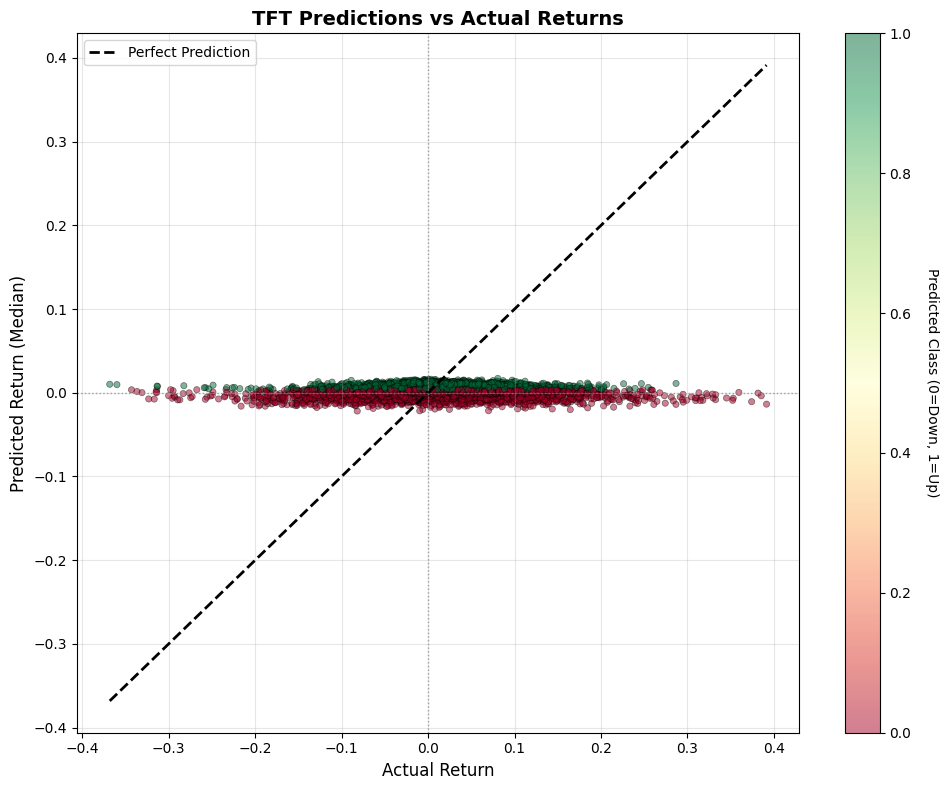

Visualizations completed


In [ ]:
# ===== CONFUSION MATRIX & VISUALIZATIONS =====
print("="*80)
print("CONFUSION MATRIX - TFT")
print("="*80)

# Confusion Matrix 
cm = confusion_matrix(y_true_class, y_pred_class)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Confusion Matrix 
ax1 = axes[0]
im = ax1.imshow(cm, cmap='Blues')

# Labels
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Down', 'Up'])
ax1.set_yticklabels(['Down', 'Up'])
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title('Confusion Matrix - TFT Test Set', fontsize=14, fontweight='bold')

# Annotations với màu tùy chỉnh
threshold = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        cell_value = cm[i, j]
        
        # False Positives - màu xám đậm
        if i == 0 and j == 1:
            text_color = "dimgray"
        else:
            text_color = "white" if cell_value > threshold else "black"
        
        ax1.text(j, i, cm[i, j], 
                ha="center", va="center", 
                color=text_color,
                fontsize=20, fontweight='bold')

plt.colorbar(im, ax=ax1)

#  Subplot 2: Quantile Predictions Distribution 
ax2 = axes[1]

# Plot distribution of quantiles
ax2.hist(q10_predictions, bins=50, alpha=0.5, label='Q10 (10th percentile)', color='red')
ax2.hist(median_predictions, bins=50, alpha=0.5, label='Q50 (Median)', color='blue')
ax2.hist(q90_predictions, bins=50, alpha=0.5, label='Q90 (90th percentile)', color='green')
ax2.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero Line')

ax2.set_xlabel('Predicted Return', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Quantile Predictions', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed Metrics 
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Values:")
print(f"  True Negatives:  {tn}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")
print(f"  True Positives:  {tp}")

print(f"\nMetrics:")
print(f"  Overall Precision: {tp/(tp+fp):.4f}")
print(f"  Overall Recall:    {tp/(tp+fn):.4f}")
print(f"  Overall Accuracy:  {(tp+tn)/(tp+tn+fp+fn):.4f}")

# Prediction vs Actual Scatter Plot 
print("\n" + "="*80)
print("PREDICTION VS ACTUAL SCATTER PLOT")
print("="*80)

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
scatter = ax.scatter(y_true_values, median_predictions, 
                     c=y_pred_class, cmap='RdYlGn', 
                     alpha=0.5, s=20, edgecolors='black', linewidths=0.5)

# Reference line (perfect prediction)
min_val = min(y_true_values.min(), median_predictions.min())
max_val = max(y_true_values.max(), median_predictions.max())
ax.plot([min_val, max_val], [min_val, max_val], 
        'k--', linewidth=2, label='Perfect Prediction')

# Zero lines
ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.axvline(0, color='gray', linestyle=':', linewidth=1, alpha=0.7)

ax.set_xlabel('Actual Return', fontsize=12)
ax.set_ylabel('Predicted Return (Median)', fontsize=12)
ax.set_title('TFT Predictions vs Actual Returns', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Predicted Class (0=Down, 1=Up)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

print("Visualizations completed")